In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import entropy
import hdbscan

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.size'] = 16  # базовый размер шрифта
plt.rcParams['axes.labelsize'] = 18  # размер меток осей
plt.rcParams['xtick.labelsize'] = 16  # размер тиков оси X
plt.rcParams['ytick.labelsize'] = 16  # размер тиков оси Y

from subprocess import check_output
print(check_output(["ls", "../input"]).decode("utf8"))

dataset_TSMC2014_NYC.csv
dataset_TSMC2014_TKY.csv



In [2]:
nyc_checkins = pd.read_csv('../input/dataset_TSMC2014_NYC.csv')
tky_checkins = pd.read_csv('../input/dataset_TSMC2014_TKY.csv')

nyc_checkins.info()
nyc_checkins.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 227428 entries, 0 to 227427
Data columns (total 8 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   userId           227428 non-null  int64  
 1   venueId          227428 non-null  object 
 2   venueCategoryId  227428 non-null  object 
 3   venueCategory    227428 non-null  object 
 4   latitude         227428 non-null  float64
 5   longitude        227428 non-null  float64
 6   timezoneOffset   227428 non-null  int64  
 7   utcTimestamp     227428 non-null  object 
dtypes: float64(2), int64(2), object(4)
memory usage: 13.9+ MB


,userId,latitude,longitude,timezoneOffset
count,227428.000000,227428.000000,227428.000000,227428.000000
mean,535.304817,40.754045,-73.974556,-253.392019
std,305.398774,0.072458,0.086209,43.234750
min,1.000000,40.550852,-74.274766,-420.000000
25%,287.000000,40.718330,-74.000633,-240.000000
50%,523.000000,40.747745,-73.983479,-240.000000
75%,793.000000,40.778374,-73.945709,-240.000000
max,1083.000000,40.988332,-73.683825,660.000000


In [11]:
def analyze(data, name="NYC"):
    # Simple analysis
    n_users = data['userId'].nunique()
    n_venues = data['venueId'].nunique()
    n_categories = data['venueCategory'].nunique()
    avg_checkins_per_user = len(data) / n_users

    print(f"Users: {n_users:,}")
    print(f"Venues: {n_venues:,}")
    print(f"Categories: {n_categories}")
    print(f"Avg checkins/user: {avg_checkins_per_user:.2f}")

    checkins_per_user = data.groupby('userId').size()
    print(f"\nCheckins per user: min={checkins_per_user.min()}, "
          f"median={checkins_per_user.median():.0f}, "
          f"max={checkins_per_user.max():,}")

    print(f"a) Checkins per user (top 10)\nb) Checkins per user (log scale)")
    plt.figure(figsize=(14, 4))
    plt.subplot(1, 2, 1)
    checkins_per_user.value_counts().sort_index().head(10).plot(kind='bar')
    plt.xlabel('Number of checkins')
    plt.ylabel('Number of users')

    plt.subplot(1, 2, 2)
    checkins_per_user.hist(bins=50, log=True)
    plt.xlabel('Number of checkins')
    plt.ylabel('Number of users (log)')
    plt.tight_layout()
    plt.show()

    # Category analysis

    """
    print(f"Top-10 categories by check-ins for {name} dataset")
    top_10 = data['venueCategory'].value_counts().head(10)
    plt.figure(figsize=(12, 8))
    sns.barplot(x=top_10.index, y=top_10.values, palette='viridis', legend=False)
    
    plt.xticks(rotation=45, ha='right')
    plt.xlabel('Category')
    plt.ylabel('Number of check-ins')
    # plt.title('10 Venue Categories by Check-ins')
    plt.tight_layout()
    plt.show()

    print(f"Top-10 categories by different users for {name} dataset")
    top_10 = data.groupby('venueCategory')['userId'].nunique().sort_values(ascending=False).head(10)

    plt.figure(figsize=(12, 8))
    sns.barplot(x=top_10.index, y=top_10.values, palette='viridis', legend=False)
    
    plt.xticks(rotation=45, ha='right')
    plt.xlabel('Category')
    plt.ylabel('Number of users')
    # plt.title('10 Venue Categories by Check-ins')
    plt.tight_layout()
    plt.show()
    
    """

    cat_by_users = data.groupby('venueCategory')['userId'].nunique().sort_values(ascending=False)
    cat_by_checkins = data['venueCategory'].value_counts()

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    cat_by_users.head(10).plot(kind='barh', ax=axes[0], color='skyblue')
    print(f"a) Top-10 categories by unique users\nb) Top-10 categories by total checkins")
    #axes[0].set_title('Top-10 Categories by Unique Users')
    axes[0].set_xlabel('Number of unique users')
    
    cat_by_checkins.head(10).plot(kind='barh', ax=axes[1], color='lightcoral')
    #axes[1].set_title('Top-10 Categories by Total Checkins')
    axes[1].set_xlabel('Total checkins')
    
    plt.tight_layout()
    plt.show()


    # Time analysis
    data['datetime_utc'] = pd.to_datetime(data['utcTimestamp'])
    def apply_timezone_offset(row):
        return row['datetime_utc'] + pd.Timedelta(minutes=row['timezoneOffset'])
    data['datetime'] = data.apply(apply_timezone_offset, axis=1)
    data['hour'] = data['datetime'].dt.hour
    data['weekday'] = data['datetime'].dt.dayofweek
    data['month'] = data['datetime'].dt.month
    hourly_checkins = data.groupby('hour').size()
    plt.figure(figsize=(18, 6))

    print(f"a) Checkins by hour\nb)Checkins by day of week\nc)Checkins by month")
    plt.subplot(1, 3, 1)
    hourly_checkins.plot(kind='bar', color='steelblue')
    plt.xlabel('Hour of day')
    plt.ylabel('Number of checkins')
    plt.subplot(1, 3, 2)
    weekday_checkins = data.groupby('weekday').size()
    weekday_checkins.index = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
    weekday_checkins.plot(kind='bar', color='coral')
    plt.subplot(1, 3, 3)
    monthly_checkins = data.groupby('month').size()
    monthly_checkins.plot(kind='bar', color='forestgreen')
    plt.tight_layout()
    plt.show()

    print("Category activity by hours, row-normalized")
    top_cats = cat_by_checkins.head(5).index
    cat_hour = data[data['venueCategory'].isin(top_cats)].groupby(['venueCategory', 'hour']).size().unstack(fill_value=0)
    cat_hour_row_norm = cat_hour.div(cat_hour.max(axis=1), axis=0)
    plt.figure(figsize=(12, 6))
    sns.heatmap(cat_hour_row_norm, cmap='YlOrRd', annot=False,
            cbar_kws={'label': 'Fraction of peak hour'})
    plt.xlabel('Hour')
    plt.ylabel('Category')
    plt.show()

    # Geo analysis
    coords = data[['latitude', 'longitude']].values
    clusterer = hdbscan.HDBSCAN(min_cluster_size=100, min_samples=10)
    data['hdb_cluster'] = clusterer.fit_predict(coords)
    n_clusters = len(set(data['hdb_cluster'])) - (1 if -1 in data['hdb_cluster'] else 0)
    print(f"HDBSCAN found {n_clusters} meaningful clusters, (min_cluster_size=100) - {n_clusters} clusters")

    plt.figure(figsize=(12, 8))
    colors = plt.cm.tab20(data['hdb_cluster'] % 20)
    plt.scatter(data['longitude'], data['latitude'], c=colors, s=1, alpha=0.5)
    plt.show()

    # Diversity analysis
    user_stats = data.groupby('userId').agg(
        n_checkins=('venueId', 'count'),
        n_unique_venues=('venueId', 'nunique'),
        n_categories=('venueCategory', 'nunique'),
        active_hours_range=('hour', lambda x: x.max() - x.min()),
        most_active_hour=('hour', lambda x: x.mode()[0] if len(x.mode()) > 0 else -1)
    )
    
    print("a) User diversity: venues vs categories")
    plt.figure(figsize=(12, 8))
    plt.scatter(user_stats['n_unique_venues'], user_stats['n_categories'], 
                alpha=0.5, s=user_stats['n_checkins']/10, c='purple')
    plt.xlabel('Unique venues visited')
    plt.ylabel('Unique categories')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    user_category_dist = pd.crosstab(data['userId'], data['venueCategory'], normalize='index')
    user_entropy = user_category_dist.apply(entropy, axis=1)
    
    print('User category diversity distribution')
    plt.figure(figsize=(10, 4))
    plt.hist(user_entropy, bins=50, alpha=0.7, color='steelblue')
    plt.xlabel('Category entropy (bits)')
    plt.ylabel('Number of users')
    plt.axvline(user_entropy.median(), color='red', linestyle='--', 
                label=f'Median: {user_entropy.median():.2f}')
    plt.legend()
    plt.show()

    # Time-based activity
    daily_checkins = data.groupby(data['datetime'].dt.date).size()
    
    print("Daily checkins over rolling window")
    plt.figure(figsize=(15, 5))
    plt.plot(pd.to_datetime(daily_checkins.index), daily_checkins.values, alpha=0.7)
    plt.xlabel('Date')
    plt.ylabel('Number of checkins')
    rolling_avg = daily_checkins.rolling(window=7, min_periods=1).mean()
    plt.plot(pd.to_datetime(rolling_avg.index), rolling_avg.values, 
             'r-', linewidth=2, label='7-day rolling average')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    print("Daily patterns: weekdays vs weekends")
    data['is_weekend'] = data['weekday'].isin([5, 6])
    weekend_pattern = data.groupby(['is_weekend', 'hour']).size().unstack(fill_value=0)
    
    plt.figure(figsize=(12, 5))
    weekend_pattern.T.plot(kind='line', marker='o', linewidth=2)
    plt.xlabel('Hour of day')
    plt.ylabel('Number of checkins')
    plt.legend(['Weekday', 'Weekend'])
    plt.grid(True, alpha=0.3)
    plt.show()

Users: 2,293
Venues: 61,858
Categories: 247
Avg checkins/user: 250.20

Checkins per user: min=100, median=173, max=2,991
a) Checkins per user (top 10)
b) Checkins per user (log scale)


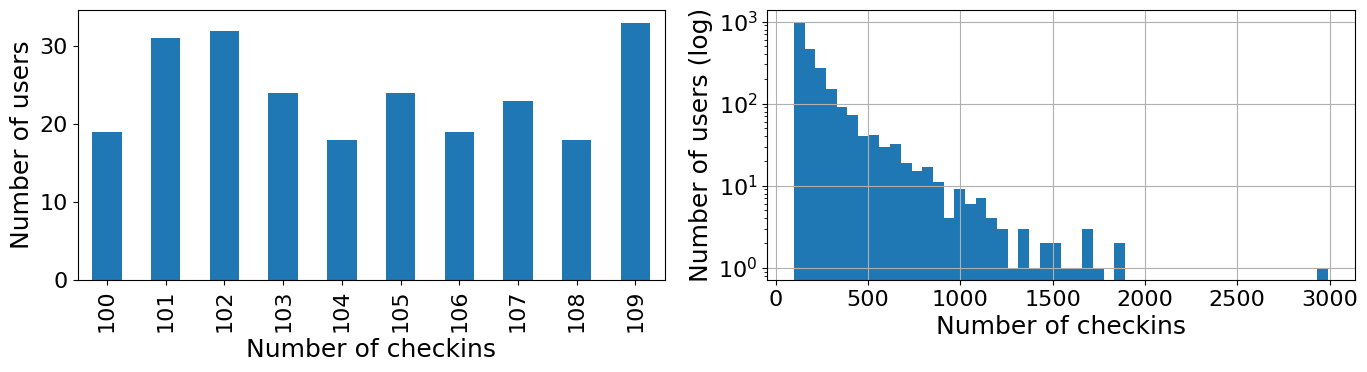

a) Top-10 categories by unique users
b) Top-10 categories by total checkins


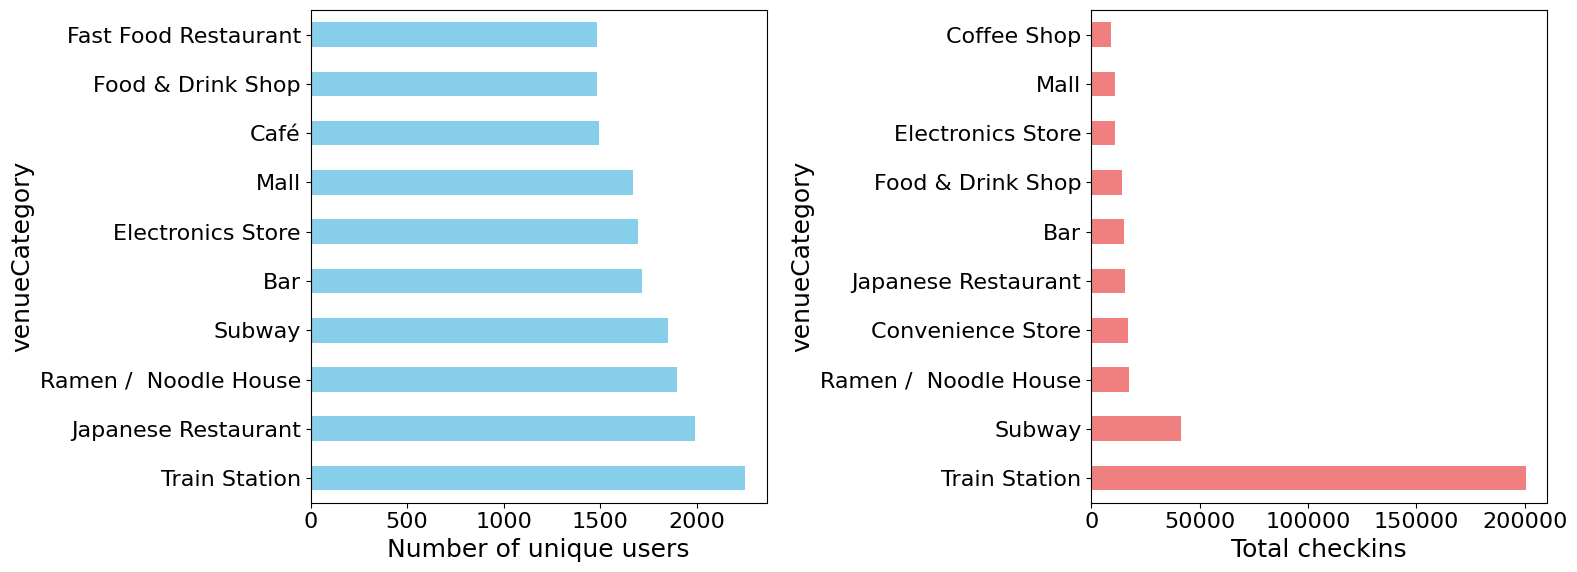

a) Checkins by hour
b)Checkins by day of week
c)Checkins by month


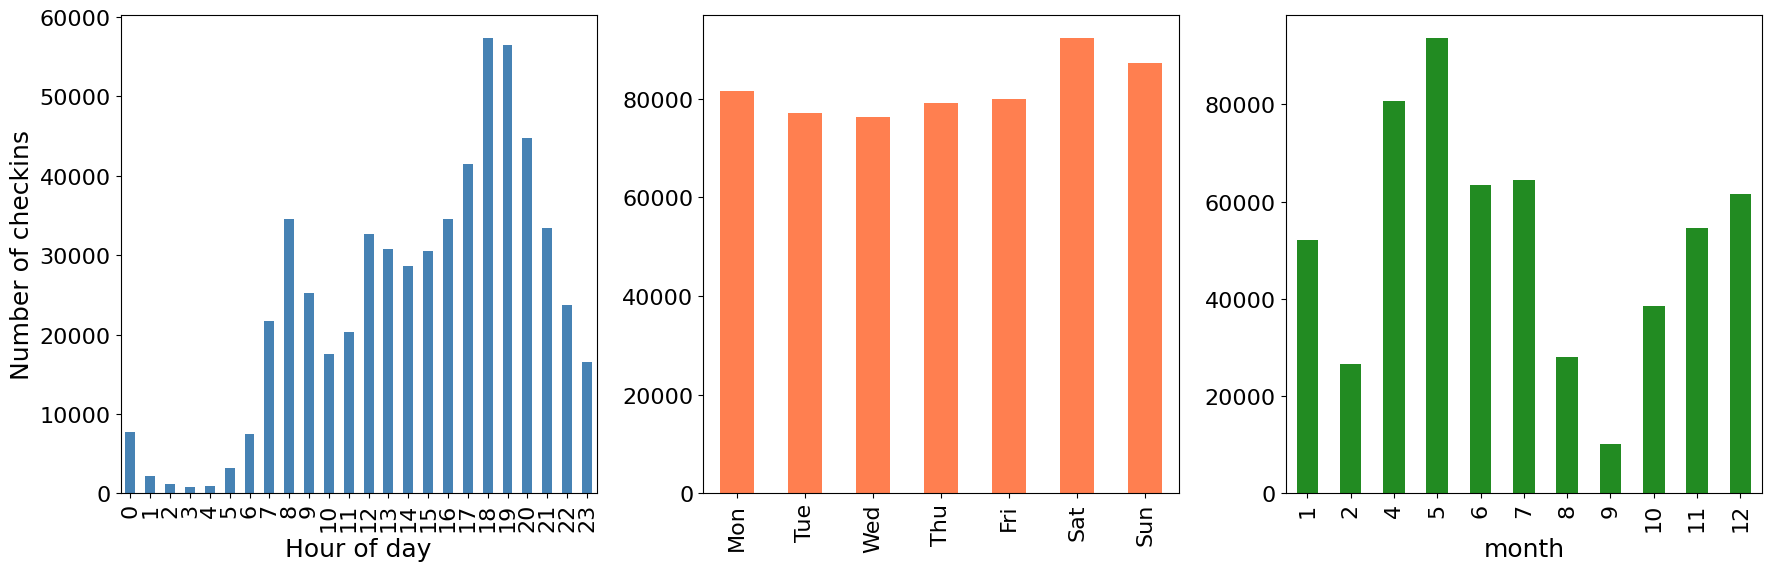

Category activity by hours, row-normalized


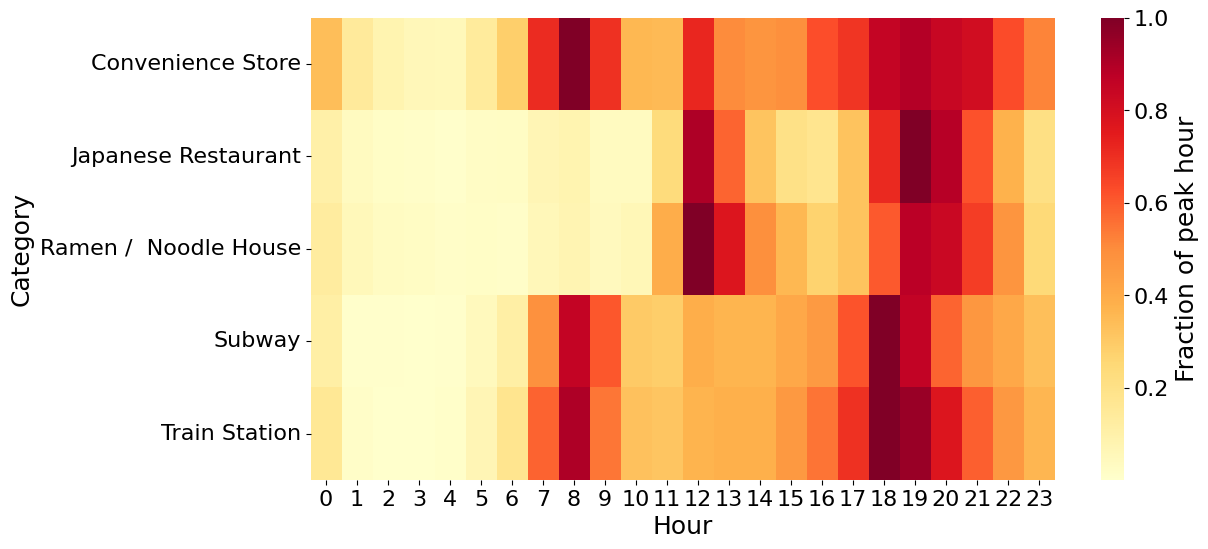

HDBSCAN found 1541 meaningful clusters, (min_cluster_size=100) - 1541 clusters


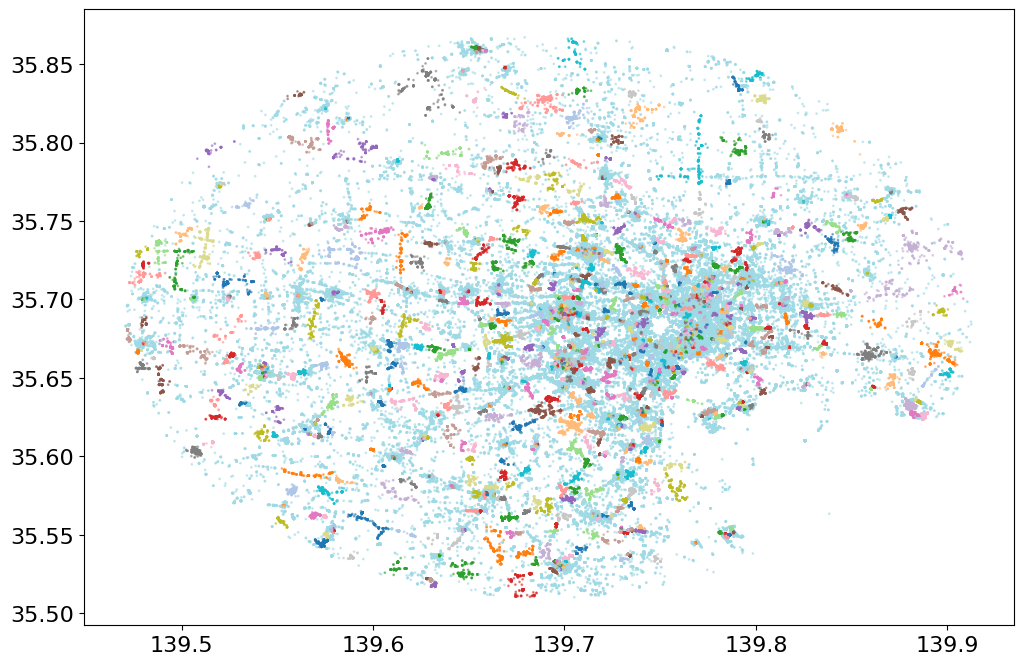

a) User diversity: venues vs categories


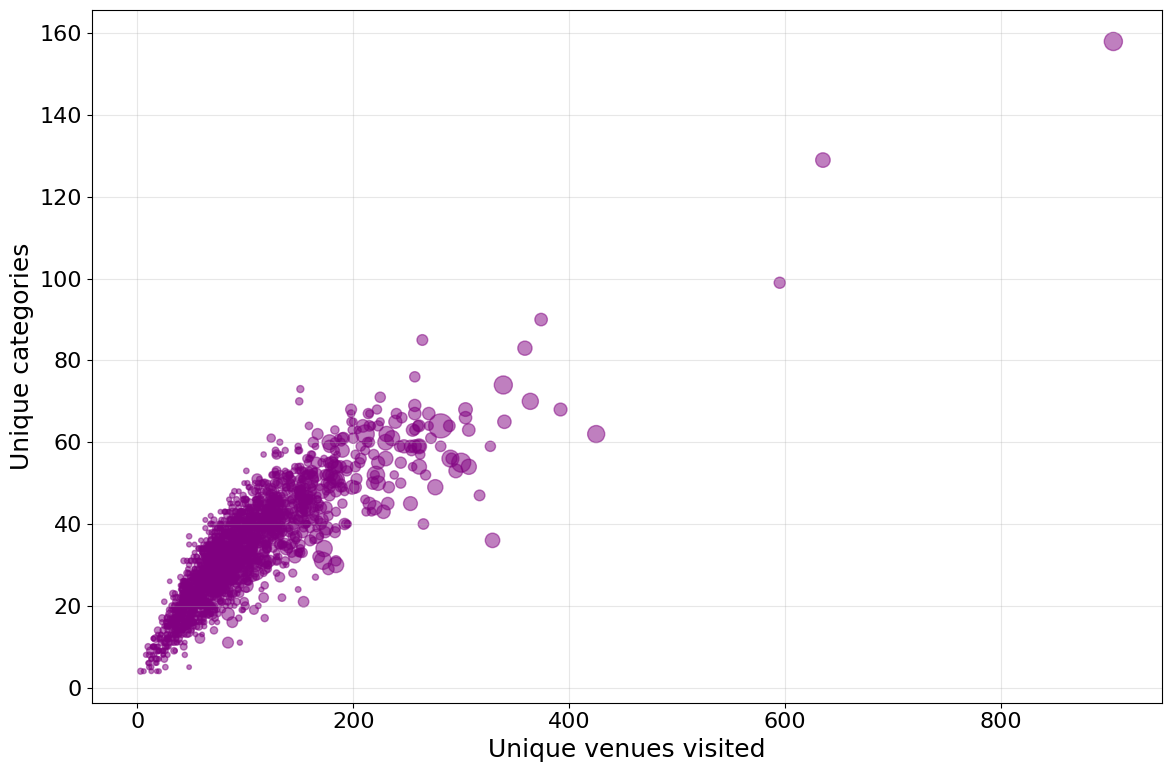

User category diversity distribution


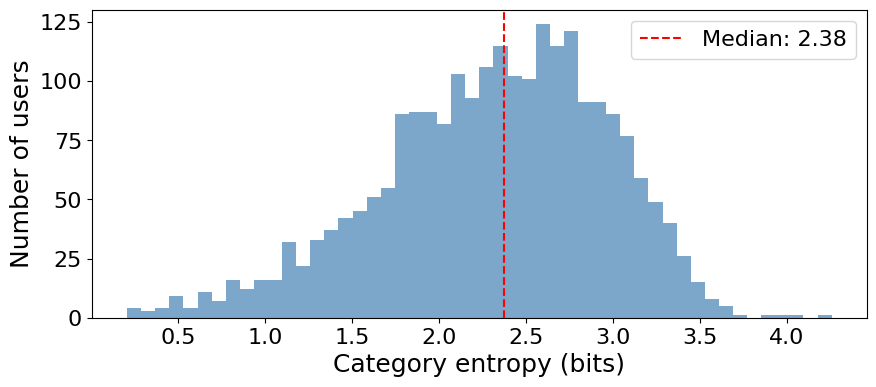

Daily checkins over rolling window


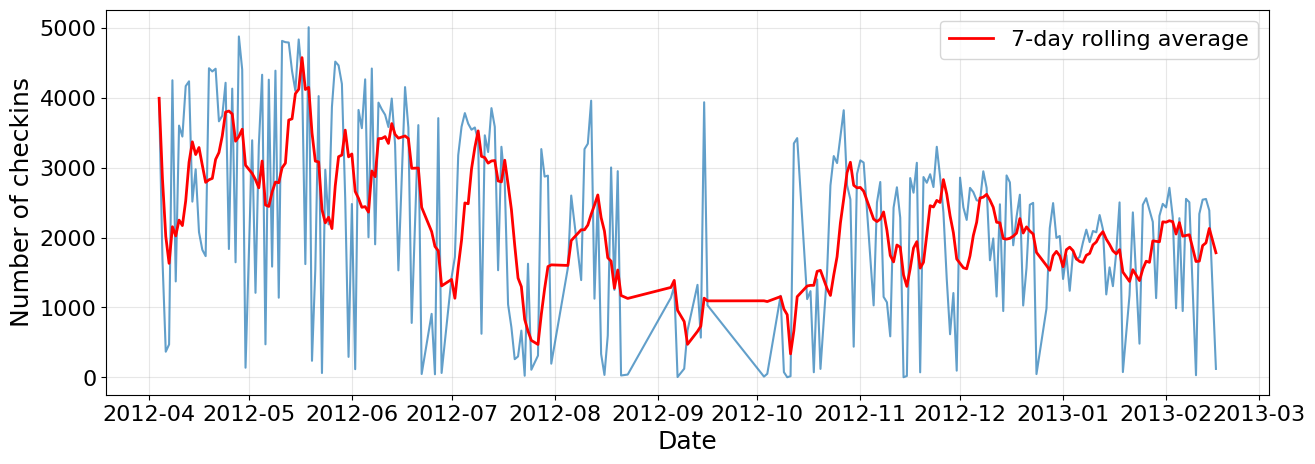

Daily patterns: weekdays vs weekends


<Figure size 1200x500 with 0 Axes>

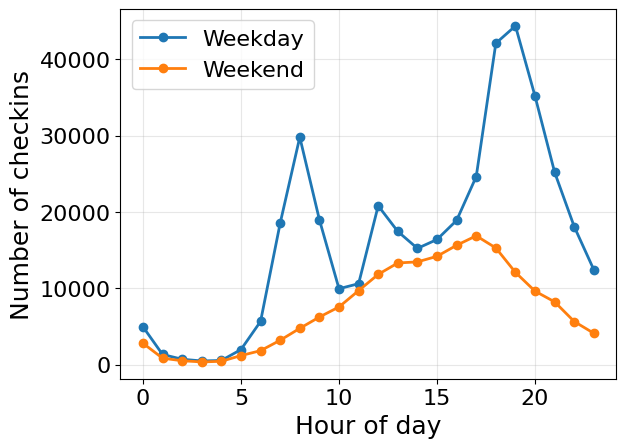

In [12]:
analyze(tky_checkins)

Users: 1,083
Venues: 38,333
Categories: 251
Avg checkins/user: 210.00

Checkins per user: min=100, median=153, max=2,697
a) Checkins per user (top 10)
b) Checkins per user (log scale)


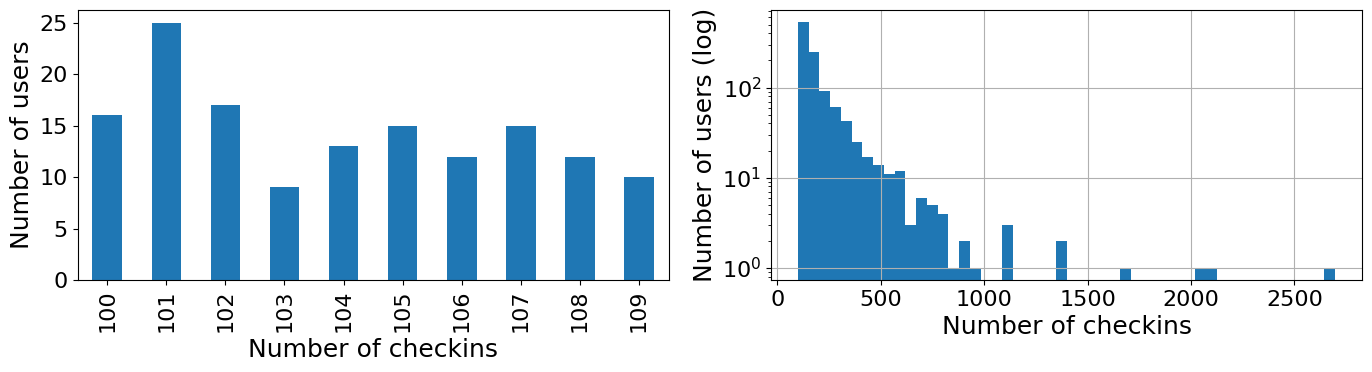

a) Top-10 categories by unique users
b) Top-10 categories by total checkins


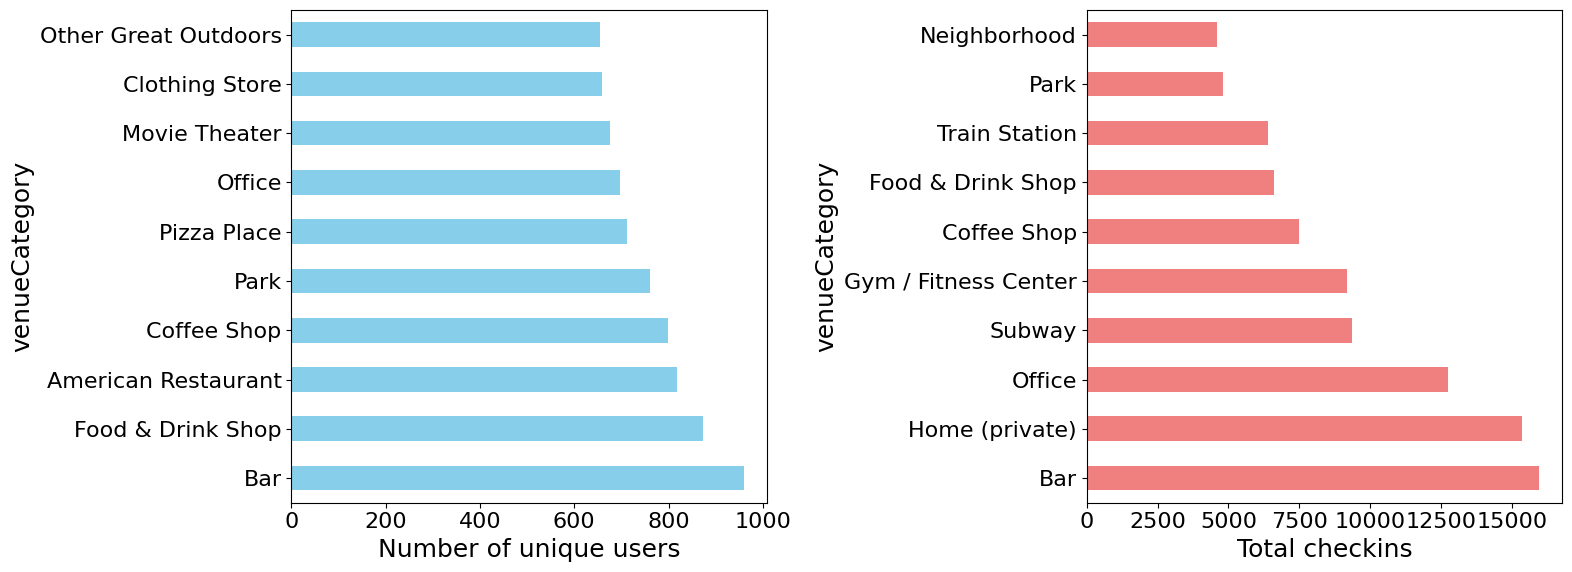

a) Checkins by hour
b)Checkins by day of week
c)Checkins by month


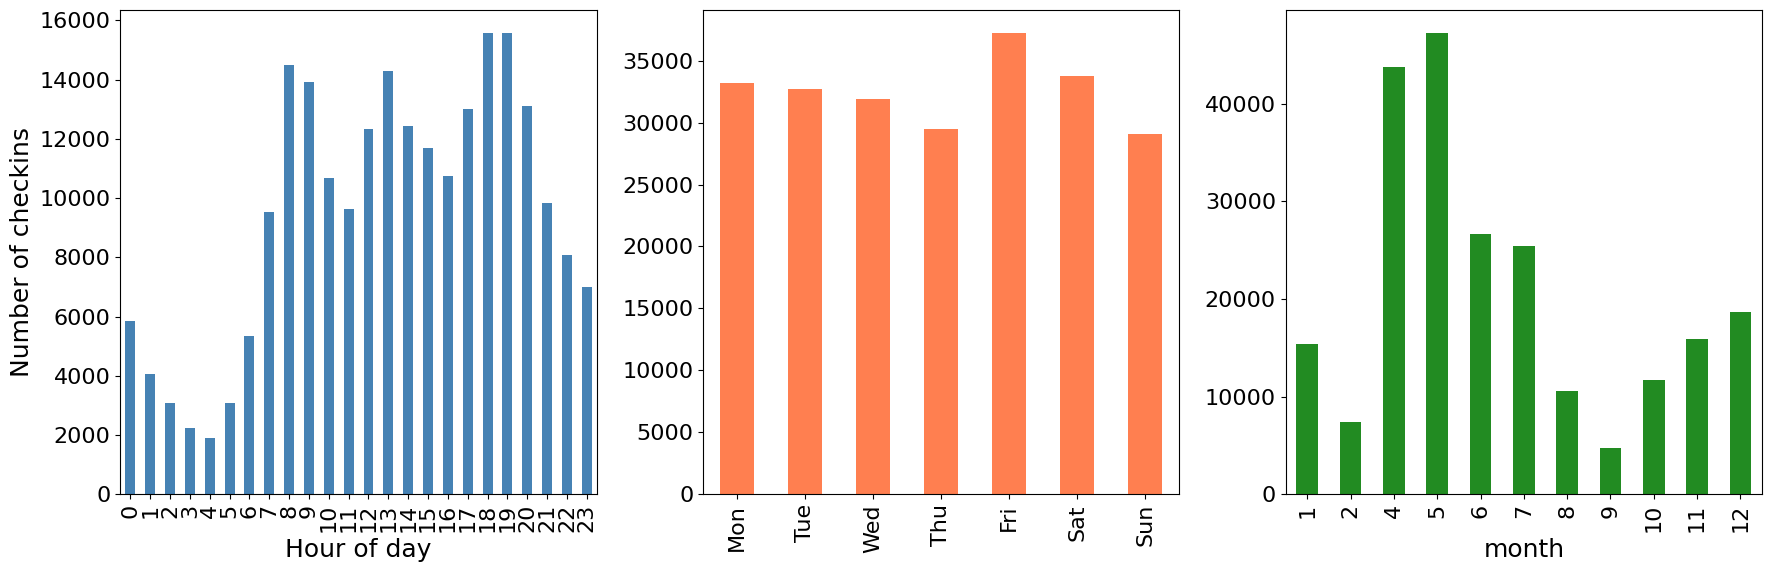

Category activity by hours, row-normalized


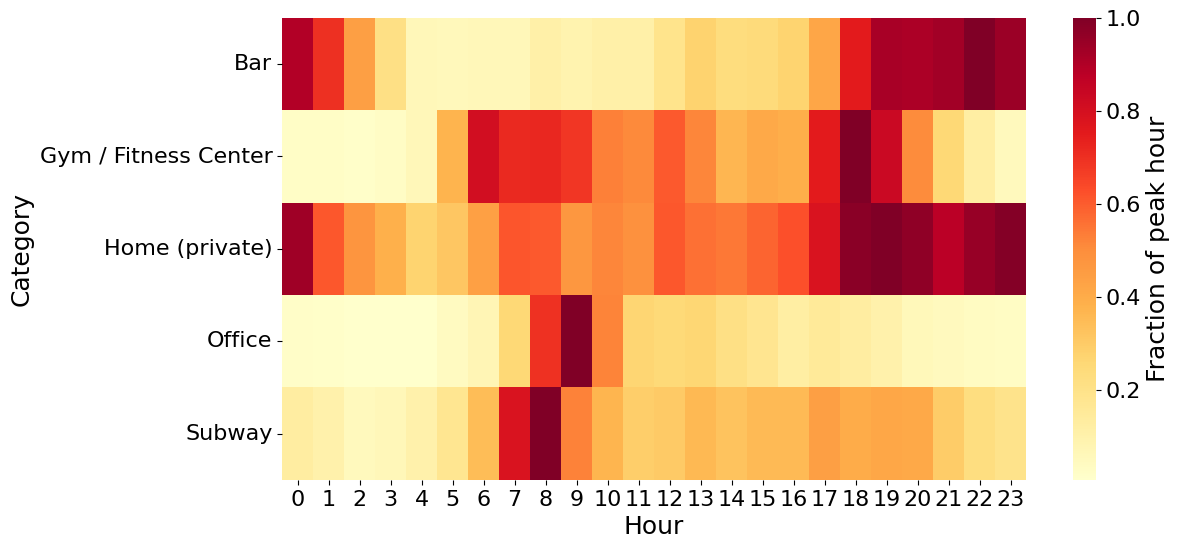

HDBSCAN found 812 meaningful clusters, (min_cluster_size=100) - 812 clusters


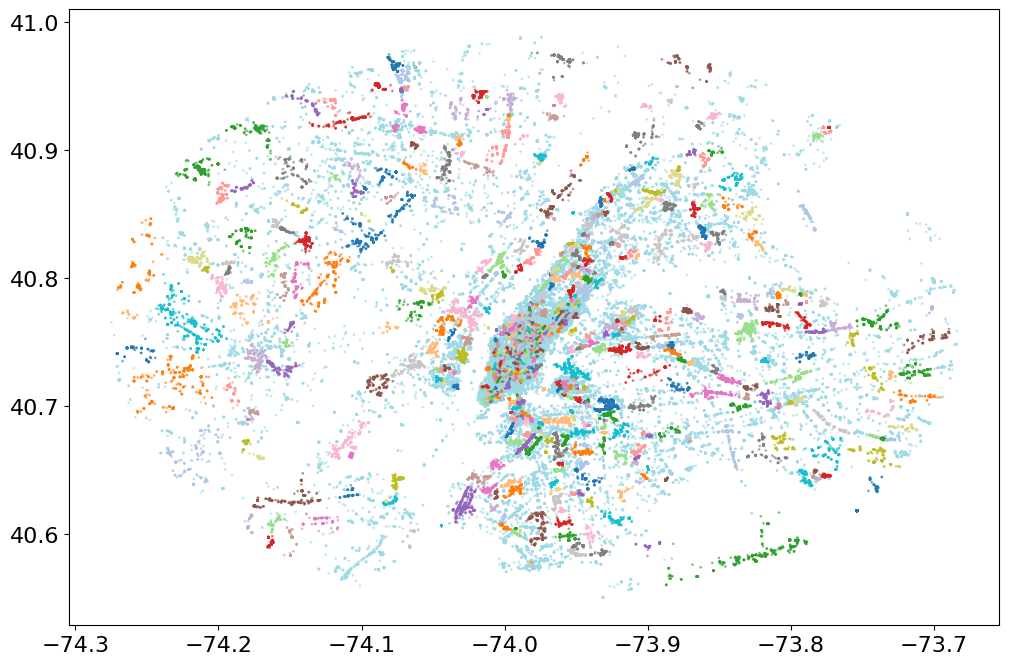

a) User diversity: venues vs categories


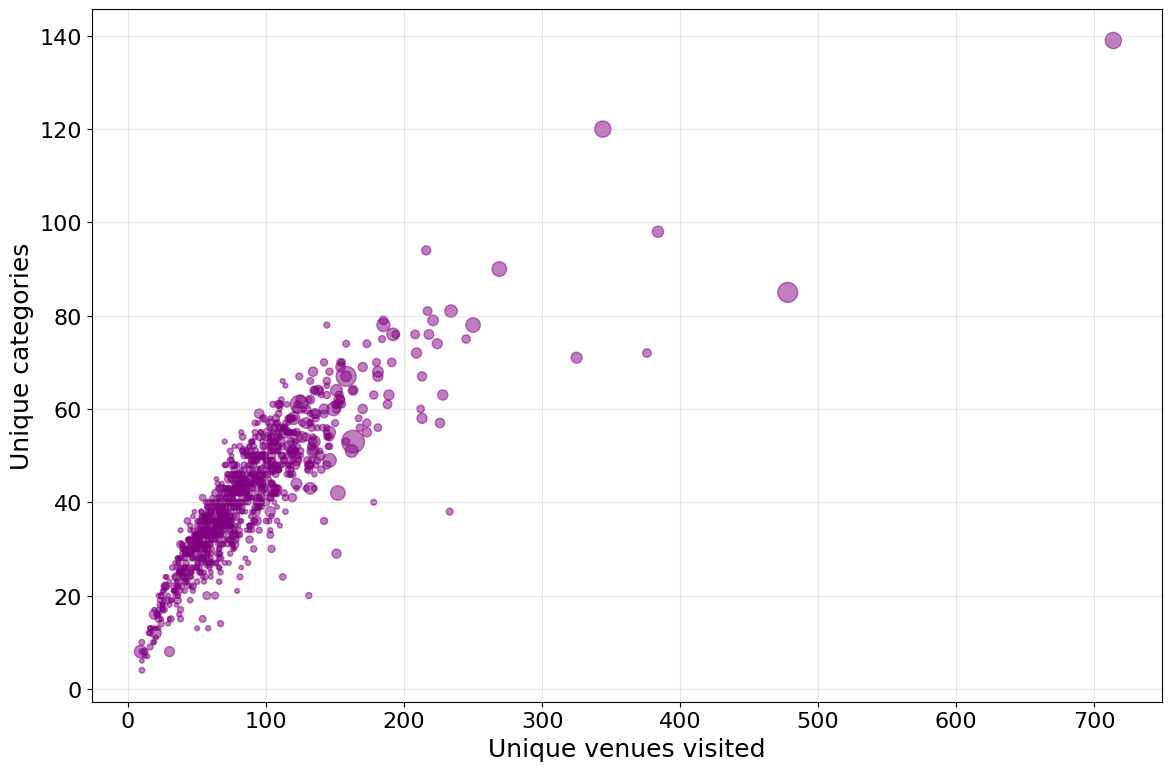

User category diversity distribution


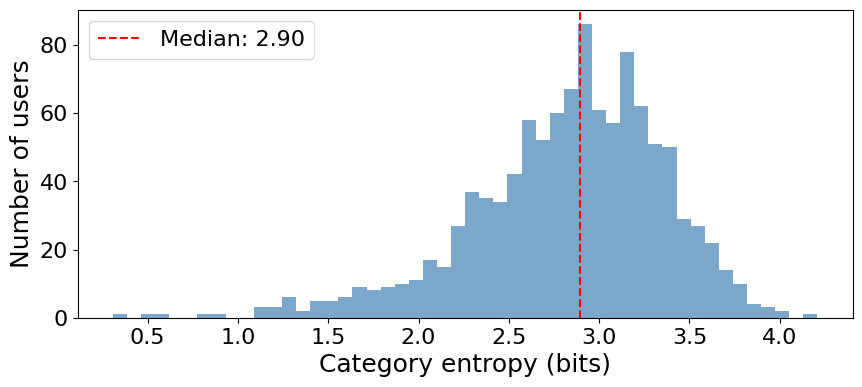

Daily checkins over rolling window


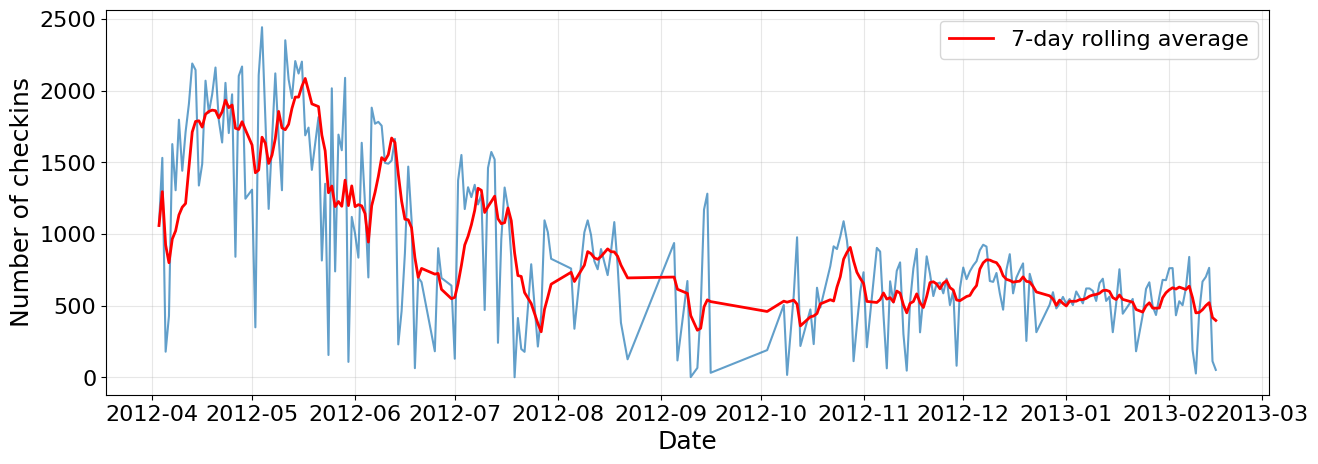

Daily patterns: weekdays vs weekends


<Figure size 1200x500 with 0 Axes>

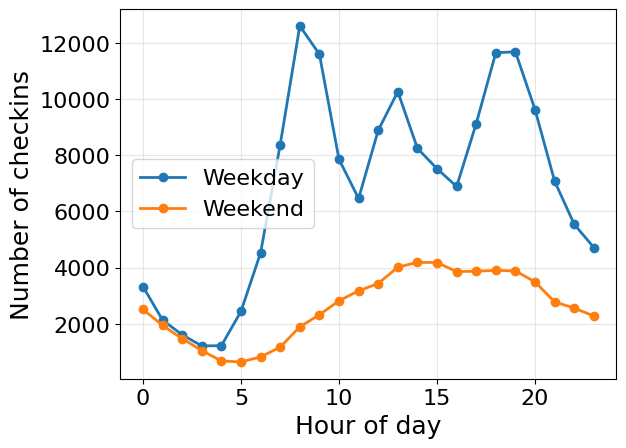

In [13]:
analyze(nyc_checkins)

In [ ]:
Following [7], [61], we use Foursquare [62] checkin records in three cities, namely, Phoenix (PHO), New York
(NY), and Singapore (SIN) from April 2012 to September
2013. Then, we filter out POIs with fewer than 10 interactions,
inactive users with fewer than 5 trajectories, and trajectories
with fewer than 3 check-in records [7]. For each user, we
take the earlier 80% of his trajectories as the training set; the
latest 10% of trajectories as the test set, and the rest 10%
as the validation set. The statistics of the three datasets are
summarized in Table II.

In [6]:
nyc_unique_lat_long = nyc_checkins.filter(['latitude', 'longitude']).groupby(['latitude', 'longitude']).count().reset_index()
tky_unique_lat_long = tky_checkins.filter(['latitude', 'longitude']).groupby(['latitude', 'longitude']).count().reset_index()

nyc_unique_lat_long.to_csv('nyc_unique_lat_long.csv', header=False, index=False)
tky_unique_lat_long.to_csv('tky_unique_lat_long.csv', header=False, index=False)